In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

In [33]:
df = pd.read_csv("../data/marketing_campaign.csv", sep="\t")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [34]:
data = df.copy()

if "ID" in data.columns:
    data.drop(
        "ID",
        axis=1,
        inplace=True
    )

if "Dt_Customer" in data.columns:
    data.drop(
        "Dt_Customer",
        axis=1,
        inplace=True
    )

In [35]:
data = df.copy()

if "ID" in data.columns:
    data.drop(
        "ID",
        axis=1,
        inplace=True
    )

if "Dt_Customer" in data.columns:
    data.drop(
        "Dt_Customer",
        axis=1,
        inplace=True
    )

In [36]:
data["Age"] = (
    2025 - data["Year_Birth"]
)

data["Total_Spending"] = (
    data["MntWines"]
    + data["MntFruits"]
    + data["MntMeatProducts"]
    + data["MntFishProducts"]
    + data["MntSweetProducts"]
    + data["MntGoldProds"]
)

data.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Spending
0,1957,Graduation,Single,58138.0,0,0,58,635,88,546,...,0,0,0,0,0,3,11,1,68,1617
1,1954,Graduation,Single,46344.0,1,1,38,11,1,6,...,0,0,0,0,0,3,11,0,71,27
2,1965,Graduation,Together,71613.0,0,0,26,426,49,127,...,0,0,0,0,0,3,11,0,60,776
3,1984,Graduation,Together,26646.0,1,0,26,11,4,20,...,0,0,0,0,0,3,11,0,41,53
4,1981,PhD,Married,58293.0,1,0,94,173,43,118,...,0,0,0,0,0,3,11,0,44,422


In [37]:
cat_cols = data.select_dtypes(
    include="object"
).columns

for col in cat_cols:

    le = LabelEncoder()

    data[col] = le.fit_transform(
        data[col].astype(str)
    )

In [38]:
data.fillna(
    data.median(numeric_only=True),
    inplace=True
)
scaler = StandardScaler()

X = scaler.fit_transform(data)

print(X.shape)


(2240, 29)


In [39]:
model = IsolationForest(
    contamination=0.05,
    random_state=42
)

labels = model.fit_predict(X)

labels[:10]

data["Anomaly"] = labels

data.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Spending,Anomaly
0,1957,2,4,58138.0,0,0,58,635,88,546,...,0,0,0,0,3,11,1,68,1617,1
1,1954,2,4,46344.0,1,1,38,11,1,6,...,0,0,0,0,3,11,0,71,27,1
2,1965,2,5,71613.0,0,0,26,426,49,127,...,0,0,0,0,3,11,0,60,776,1
3,1984,2,5,26646.0,1,0,26,11,4,20,...,0,0,0,0,3,11,0,41,53,1
4,1981,4,3,58293.0,1,0,94,173,43,118,...,0,0,0,0,3,11,0,44,422,1


In [40]:
normal_count = (
    data["Anomaly"] == 1
).sum()

anomaly_count = (
    data["Anomaly"] == -1
).sum()

print("Normal Records :", normal_count)
print("Anomalies :", anomaly_count)

Normal Records : 2128
Anomalies : 112


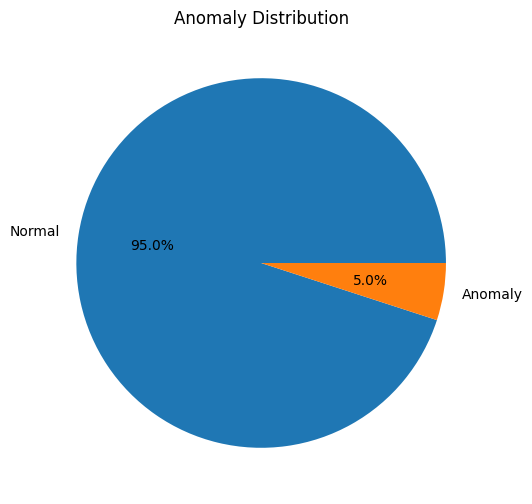

In [41]:
plt.figure(figsize=(6,6))

plt.pie(
    [normal_count, anomaly_count],
    labels=["Normal", "Anomaly"],
    autopct="%1.1f%%"
)

plt.title(
    "Anomaly Distribution"
)

plt.show()

In [42]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(X)

X_pca.shape

pca_df = pd.DataFrame(
    {
        "PC1": X_pca[:,0],
        "PC2": X_pca[:,1],
        "Anomaly": labels
    }
)

pca_df.head()

,PC1,PC2,Anomaly
0,4.174915,-0.119788,1
1,-2.472845,-1.428233,1
2,1.626062,-0.172088,1
3,-2.763414,1.893988,1
4,-0.577270,0.840277,1


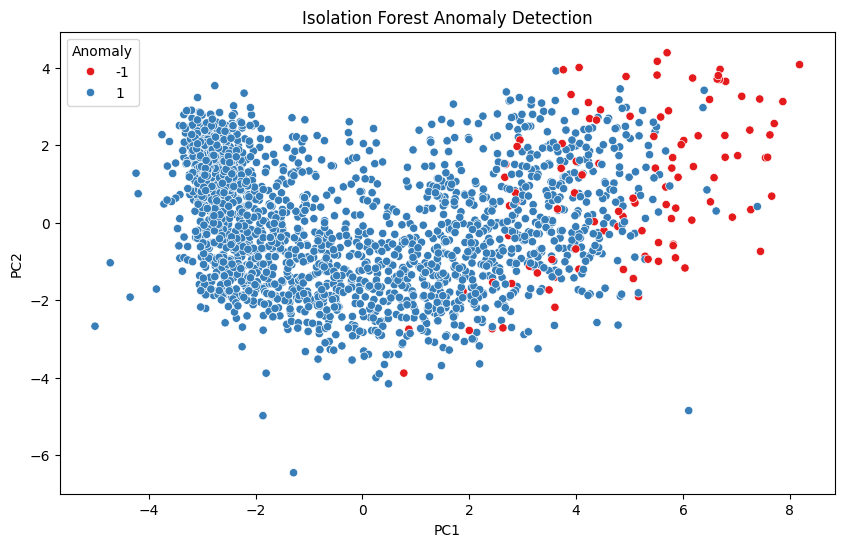

In [43]:
plt.figure(
    figsize=(10,6)
)

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Anomaly",
    palette="Set1"
)

plt.title(
    "Isolation Forest Anomaly Detection"
)

plt.show()

In [44]:
anomalies = data[
    data["Anomaly"] == -1
]

anomalies.head()

print(
    "Total Anomalies Found:",
    len(anomalies)
)

anomalies.describe()
anomalies[
    [
        "Income",
        "Total_Spending",
        "Age"
    ]
].head(20)


Total Anomalies Found: 112


,Income,Total_Spending,Age
15,82800.0,1315,79
21,2447.0,1730,46
27,51381.5,637,39
39,48948.0,902,82
53,82582.0,1617,48
55,82384.0,1957,70
67,88194.0,1274,46
111,68126.0,1820,34
124,101970.0,1135,42
155,69372.0,1381,76


In [50]:
import os
import joblib

os.makedirs(
    "../models",
    exist_ok=True
)

joblib.dump(
    model,
    "../models/isolation_forest.pkl"
)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Model and scaler saved successfully")

Model and scaler saved successfully
